In [14]:
# @title Texto de título predeterminado
from IPython.display import display, HTML as html_display
style = """<style>
/* Estilos base */
.andromeda-body {
  background-color: #23262e;
  color: #e3e6ed;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
  padding: 20px;
  line-height: 1.6;
  border-radius: 8px;
}

/* Títulos */
.andromeda-body h1 {
  font-size: 1.8em;
  font-weight: bold;
  color: #00e8c6;
  text-transform: uppercase;
  letter-spacing: 2px;
  border-bottom: 2px solid #ff4151;
  padding-bottom: 10px;
  text-shadow: 0 0 10px rgba(0, 232, 198, 0.5);
}

/* Párrafos */
.andromeda-body p {
  margin-bottom: 15px;
  font-size: 1.5em;
  padding: 0 20px ;
}

/* Figure */
.andromeda-body figure {
  background-color: #2b303b;
  border: 2px solid #00e8c6; /* Neon green border */
  border-radius: 8px;
  padding: 15px;
  margin: 20px 0;
  box-shadow: 0 0 2px #00e8c6, 0 0 5px #ff4151, 0 0 5px #00e8c6; /* Neon glow effect */

  transition: transform 0.3s ease, box-shadow 0.3s ease, border-color 0.3s ease; /* Added border-color to transition */
}

.andromeda-body figure:hover {
  transform: translateY(-5px);
  box-shadow: 0 0 5px #00ffff, 0 0 5px #00e8c6, 0 0 15px #00ffff; /* Enhanced glow on hover with brighter cyan/green */
  border-color: #00ffff; /* Neon cyan border on hover */
}
</style>
"""
def display_html(h1=None,p1=0,p2=0,p3=0,p4=0,p5=0,p6=0,p7=0,p8=0,p9=0,p10=0):
  def get_paragraph_html(p_val):
      if p_val == 0:
          return ''
      elif isinstance(p_val, tuple):
          bold_part = f"<b>{p_val[0]}</b>" if p_val else ""
          normal_part = p_val[1] if len(p_val) > 1 else ""
          return f"<p>{bold_part}{normal_part}</p>"
      else:
          return f"<p>{p_val}</p>"

  codigo_html = f"""
  {style}
  <div class="andromeda-body">
    <figure>
    {f"<h1>{h1}</h1>" if h1 is not None else ''}
    {get_paragraph_html(p1)}
    {get_paragraph_html(p2)}
    {get_paragraph_html(p3)}
    {get_paragraph_html(p4)}
    {get_paragraph_html(p5)}
    {get_paragraph_html(p6)}
    {get_paragraph_html(p7)}
    {get_paragraph_html(p8)}
    {get_paragraph_html(p9)}
    {get_paragraph_html(p10)}
    </figure>
  </div>
  """
  return codigo_html

presentacion = display_html('Actividad práctica: comparación de métodos de escalamiento en Scikit-learn')

display(html_display(presentacion))

In [15]:
# @title Texto de título predeterminado

text = display_html(None,'Importando las modulos especificos que se van a utilizar')

display(html_display(text))

In [16]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

# importando las modulos especificos que se van a utilizar
import matplotlib as mpl
import numpy as np
import pandas as pd
from matplotlib import cm
from matplotlib import pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import (
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
    minmax_scale,
)


In [17]:
# @title Texto de título predeterminado

text = display_html(None,'separando los valores independientes de la variable objetivo')

display(html_display(text))

In [18]:

# utilizando el dataset de fetch_california_housing que brinda sklearn
dataset = fetch_california_housing()
X_full, y_full = dataset.data, dataset.target
feature_names = dataset.feature_names
df = pd.DataFrame(X_full, columns=feature_names)

print('ratio minimo',df['Population'].min(),',','ratio maximo',df['Population'].max())
df.head()

ratio minimo 3.0 , ratio maximo 35682.0


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [19]:
# @title Texto de título predeterminado
text = display_html(None,("MedInc : ", "Mediana de los ingresos en la manzana"),
("HouseAge :", "Mediana de la antigüedad de las casas en la manzana"),
("AveRooms : ", "Promedio de habitaciones por casa"),
("AveBedrms : ","Promedio de dormitorios por casa") ,
("Population : ", "Población de la manzana"),
("AveOccup : ","Promedio de ocupantes por casa"),
("Latitude : ","Latitud de la manzana"),
("Longitude : ","Longitud de la manzana",),
('MedHouseVal (variable objetivo) : ','la mediana del valor de las casas de la manzana.'),
'cada registro representa un "block group" o un ratio de manzanas que representa de 3 a 35682 personas por registro')

text11 = display_html(None,('target : ','valor medio de las casas'))

display(html_display(text))
display(html_display(text11))


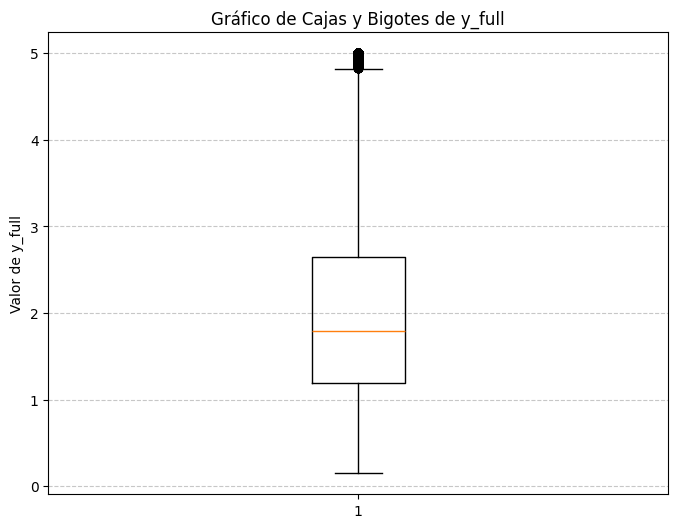

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.boxplot(y_full)
plt.title('Gráfico de Cajas y Bigotes de y_full')
plt.ylabel('Valor de y_full')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

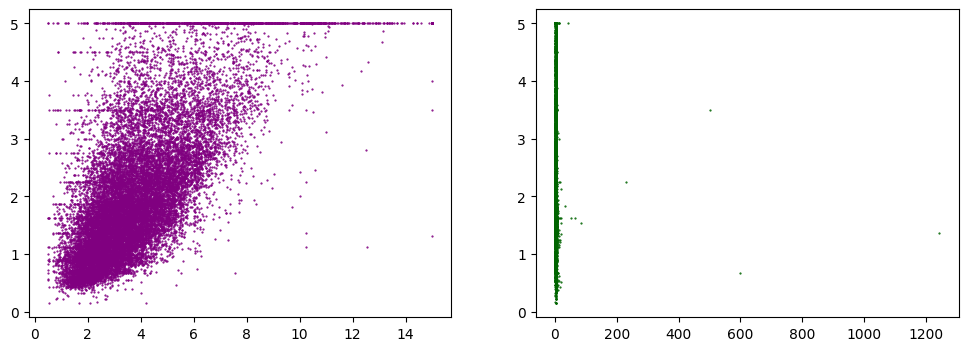

In [21]:

feature_mapping = {
    "MedInc": "Median income in block",
    "HouseAge": "Median house age in block",
    "AveRooms": "Average number of rooms",
    "AveBedrms": "Average number of bedrooms",
    "Population": "Block population",
    "AveOccup": "Average house occupancy",
    "Latitude": "House block latitude",
    "Longitude": "House block longitude",
}

# Take only 2 features to make visualization easier
# Feature MedInc has a long tail distribution.
# Feature AveOccup has a few but very large outliers.
'''
tomando la mediana de los ingresos en la manzana y el promedio de ocupantes por casa para el tratamiento de outliers
'''
features = ["MedInc", "AveOccup"]
''' capturando el orden de las columnas y MedInc, AveOccup'''
features_idx = [feature_names.index(feature) for feature in features]
X = X_full[:, features_idx]

''' X toma de todos los valores de la matrix x_full que corresponden a MedInc y AveOccup de la segunda capa'''

fig_X,ax_X = plt.subplots(1,2,figsize=(12,4))
ax_X[0].scatter(x=X[:,0],y=y_full,s=0.3,color='purple')
ax_X[1].scatter(x=X[:,1],y=y_full,s=0.3,color='darkgreen')


text = display_html(None,('MedInc',' - Se puede ver como hay una correlación moderadamente positiva entre las Mediana de los ingresos en la manzana y la variable objetivo, sin embargo existen valores altos de las features que no tiene una imagen acendente como se esperaria, esto le quita fuerza a la correlación'),
                      '- Se puede ver como hay una alta concentración de promedio de precio en 500.000USD, esto puede deberse a que cuando se realizó el senso que relleno este dataSet el cuestionario tenia una casilla de "500.000USD o más " y no se conto que habrian 27 areas en donde el promedio de precios seria mayor a dicho monto',
                      ('AveOccup',' - Con respecto a la correlación entre el Promedio de ocupantes por casa se puede ver como hay valores extremos atipicos que distorciona la correlación positiva, haciedola mas pronunciada de lo que quizas sea'),
                      '- Lo que haria en este caso seria directamente cortar los registros con valores extremos atipicos en este apartado a partir de un promedio razonable de ocupantes por casa, cortando así valores extremos como (1200)')
display(html_display(text))


In [22]:
print('cantidad de registros con promedio de precio igual o mayot a 500.000USD',len(y_full[y_full == 5.0]))

cantidad de registros con promedio de precio igual o mayot a 500.000USD 27


In [23]:
# @title Texto de título predeterminado
text = display_html('distribution','distribution es una lista de tuplas en donde contiene el nombre de cada tipo de escalamiento y los datos escalados correspondientes.',
                    ('- (1) scaling'),
                    ('- (2) min-max'),
                    ('- (3) max-abs'),
                    ('- (4) robust scaler'),
                    ('- (5) power transformation (Yeo-Johnson)'),
                    ('- (6) power transformation (Box-Cox)'),
                    ('- (7) quantile transformation (uniform pdf)'),
                    ('- (8) quantile transformation (gaussian pdf)'),
                    ('- (9) normalizing')
                    )

display(html_display(text))


In [27]:

distributions = [
    # la primera tupla de la lista contiene los datos de MedInc y AveOccup sin transformar
    ("Unscaled data", X),
    ("Data after standard scaling", StandardScaler().fit_transform(X)),
    ("Data after min-max scaling", MinMaxScaler().fit_transform(X)),
    ("Data after max-abs scaling", MaxAbsScaler().fit_transform(X)),
    (
        "Data after robust scaling",
        RobustScaler(quantile_range=(25, 75)).fit_transform(X),
    ),
    (
        "Data usd after power transformation (Yeo-Johnson)",
        PowerTransformer(method="yeo-johnson").fit_transform(X),
    ),
    (
        "Data after power transformation (Box-Cox)",
        PowerTransformer(method="box-cox").fit_transform(X),
    ),
    (
        "Data after quantile transformation (uniform pdf)",
        QuantileTransformer(
            output_distribution="uniform", random_state=42
        ).fit_transform(X),
    ),
    (
        "Data after quantile transformation (gaussian pdf)",
        QuantileTransformer(
            output_distribution="normal", random_state=42
        ).fit_transform(X),
    ),
    ("Data after sample-wise L2 normalizing", Normalizer().fit_transform(X)),
]

In [28]:
# @title Texto de título predeterminado

def create_axes(title, figsize=(16, 6)):
    fig = plt.figure(figsize=figsize)
    fig.suptitle(title)
    '''
    crea un lienzo con un figsize que se le pasa como parametro, (16,6) por defecto y con un titulo que se le pasa como parametro
    '''
    # define the axis for the first plot
    left, width = 0.1, 0.22
    bottom, height = 0.1, 0.7
    bottom_h = height + 0.15
    left_h = left + width + 0.02
    '''
    definiendo las proporciones de los ejes del primer plot
    '''

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, 0.1]
    rect_histy = [left_h, bottom, 0.05, height]


    ax_scatter = plt.axes(rect_scatter)
    ax_histx = plt.axes(rect_histx)
    ax_histy = plt.axes(rect_histy)

    '''
      definiendo los axes de scatter, histx y histy
    '''
    # define the axis for the zoomed-in plot
    left = width + left + 0.10
    left_h = left + width + 0.02


    '''
      definiendo los axes para el zoom de scatter, histx y histy
    '''

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, 0.5]
    rect_histy = [left_h, bottom, 0.05, height]

    ax_scatter_zoom = plt.axes(rect_scatter)
    ax_histx_zoom = plt.axes(rect_histx)
    ax_histy_zoom = plt.axes(rect_histy)

    # define the axis for the colorbar
    left, width = width + left + 0.13, 0.01


    rect_colorbar = [left, bottom, width, height]
    ax_colorbar = plt.axes(rect_colorbar)

    return (
        (ax_scatter, ax_histy, ax_histx),
        (ax_scatter_zoom, ax_histy_zoom, ax_histx_zoom),
        ax_colorbar,
    )


def plot_distribution(axes, X, y, hist_nbins=50, title="", x0_label="", x1_label=""):
    ax, hist_X1, hist_X0 = axes

    ax.set_title(title)
    ax.set_xlabel(x0_label)
    ax.set_ylabel(x1_label)

    # The scatter plot
    colors = cmap(y)
    ax.scatter(X[:, 0], X[:, 1], alpha=0.5, marker="o", s=5, lw=0, c=colors)

    # Removing the top and the right spine for aesthetics
    # make nice axis layout
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10))

    # Histogram for axis X1 (feature 5)
    hist_X1.set_ylim(ax.get_ylim())
    hist_X1.hist(
        X[:, 1], bins=hist_nbins, orientation="horizontal", color="grey", ec="grey"
    )
    hist_X1.axis("off")

    # Histogram for axis X0 (feature 0)
    hist_X0.set_xlim(ax.get_xlim())
    hist_X0.hist(
        X[:, 0], bins=hist_nbins, orientation="vertical", color="grey", ec="grey"
    )
    hist_X0.axis("off")

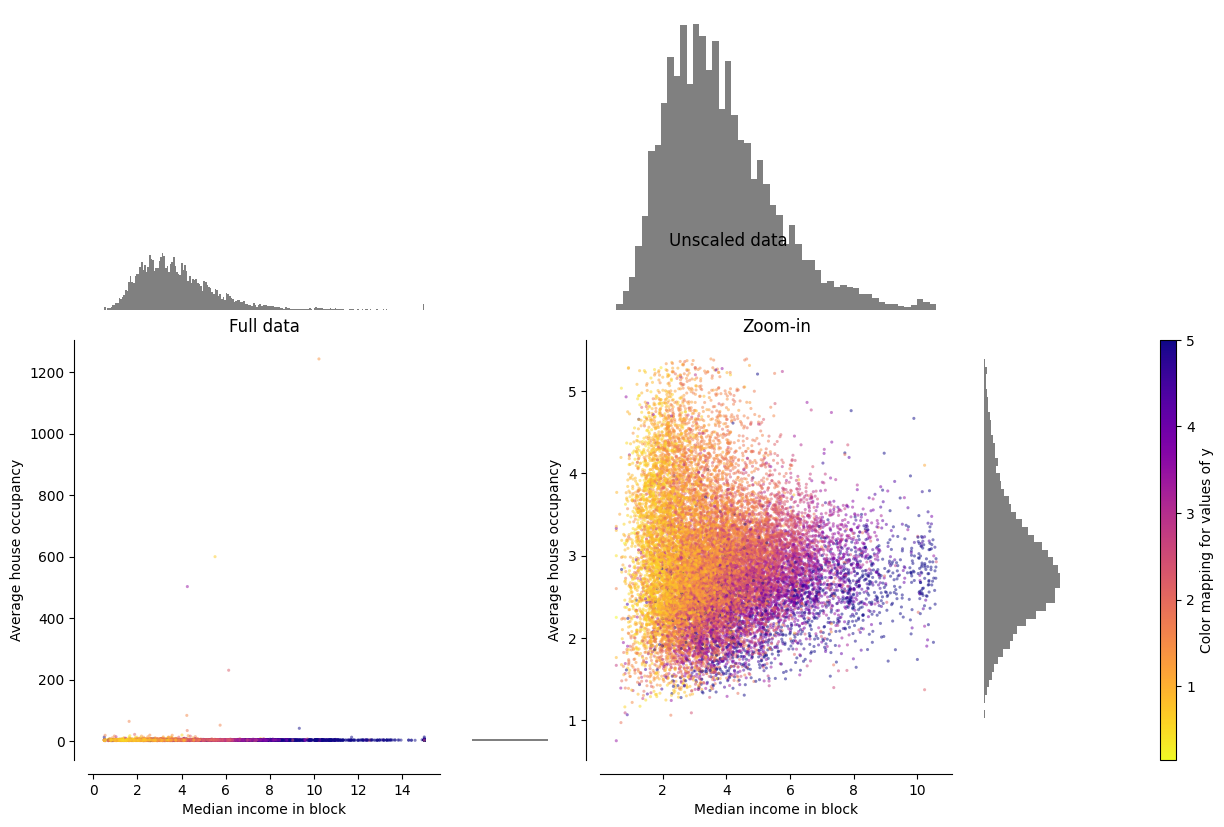

In [29]:

# scale the output between 0 and 1 for the colorbar
y = minmax_scale(y_full)

# plasma does not exist in matplotlib < 1.5
cmap = getattr(cm, "plasma_r", cm.hot_r)


def make_plot(item_idx):
    title, X = distributions[item_idx]
    ax_zoom_out, ax_zoom_in, ax_colorbar = create_axes(title)
    axarr = (ax_zoom_out, ax_zoom_in)
    plot_distribution(
        axarr[0],
        X,
        y,
        hist_nbins=200,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Full data",
    )

    # zoom-in
    zoom_in_percentile_range = (0, 99)
    cutoffs_X0 = np.percentile(X[:, 0], zoom_in_percentile_range)
    cutoffs_X1 = np.percentile(X[:, 1], zoom_in_percentile_range)

    non_outliers_mask = np.all(X > [cutoffs_X0[0], cutoffs_X1[0]], axis=1) & np.all(
        X < [cutoffs_X0[1], cutoffs_X1[1]], axis=1
    )
    plot_distribution(
        axarr[1],
        X[non_outliers_mask],
        y[non_outliers_mask],
        hist_nbins=50,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Zoom-in",
    )

    norm = mpl.colors.Normalize(y_full.min(), y_full.max())
    mpl.colorbar.ColorbarBase(
        ax_colorbar,
        cmap=cmap,
        norm=norm,
        orientation="vertical",
        label="Color mapping for values of y",
    )

text10 = display_html('Datos sin procesar',
                      ('- Descripción del gráfico antes de procesar:', 'En el primer gráfico de dispersión de los datos sin preprocesar se puede observar cómo los valores extremos del promedio de ocupación por casa aplanan la varianza visual de los datos normales; los promedios de ocupación, como lo puede ser el rango de 1 a 10, quedan matemáticamente muy cerca.'),
                      '- En el histograma de promedio de ingreso medio se puede ver cómo hay presencia de valores atípicos altos (hay pocas familias o grupos de personas en proporción que ganan mucho más que el resto de las familias).',
)
display(html_display(text10))

make_plot(0)

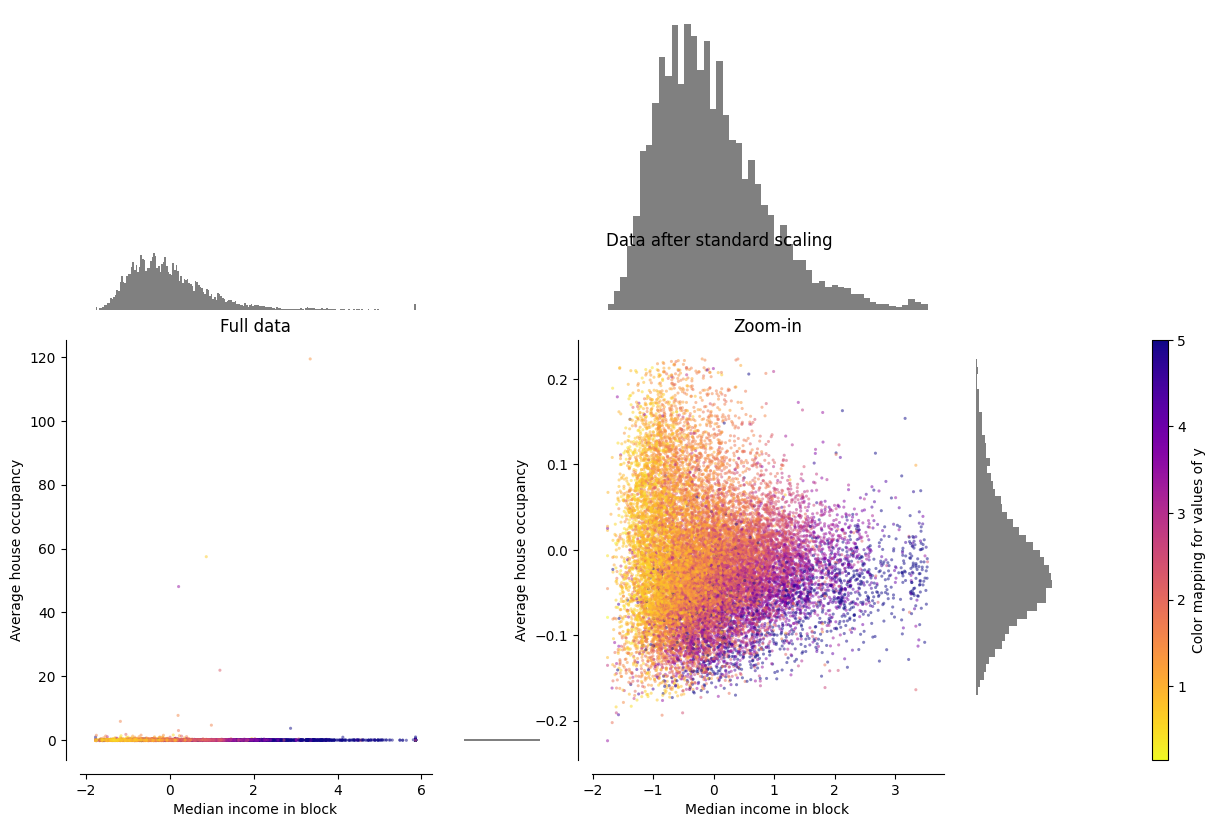

In [30]:
# @title Texto de título predeterminado
text10 = display_html('StandardScaler',
                      '- A cada elemento se le resta el promedio y se divide por la desviación estándar.',
                      '- Los extremos son iguales a la desviación estándar y el promedio es igual a 0.',
                      ('Descripción del gráfico después de procesar', '- Cuando se aplica StandardScaler los outliers siguen estando presentes, ya que estos afectan al valor de la desviación estándar y del promedio (métricas que utiliza StandardScaler para escalar los datos).'),
                      '- StandardScaler funciona bien cuando los datos tienen una distribución aproximadamente gaussiana (normal).',
                      '')
display(html_display(text10))
make_plot(1)

$$ z = \frac{x - \mu}{\sigma} $$

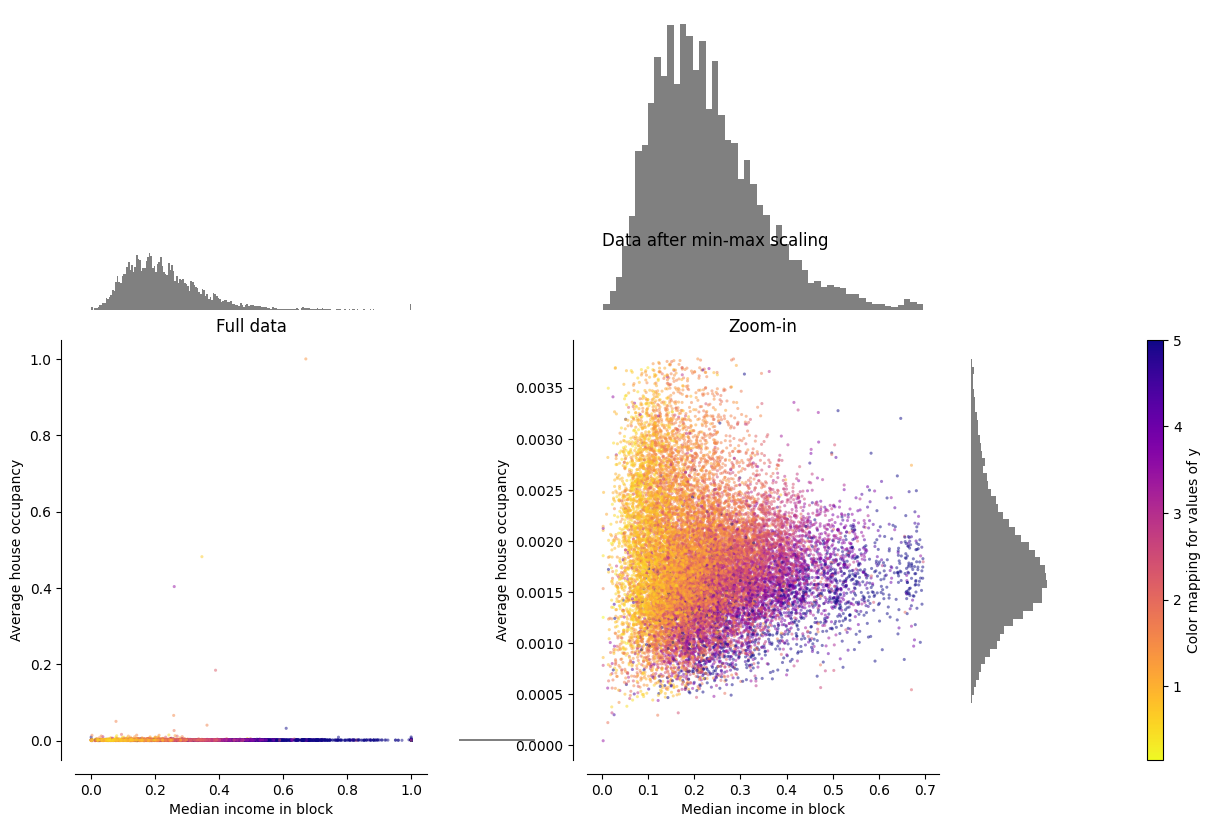

In [31]:
# @title Texto de título predeterminado
text10 = display_html('Min-Max Scaling',
                      '- A cada elemento le resta el valor mínimo y lo divide por la diferencia entre el valor máximo y el valor mínimo, quedando en un rango de 0 a 1.',
                      '- Al utilizar los valores mínimos y máximos para realizar el escalamiento, este tipo de método es muy sensible a los valores atípicos (outliers) tanto máximos como mínimos.',
                      '- En el gráfico de zoom se puede ver cómo en la dimensión de "average house occupancy" el rango va de 0.0 a 0.35, dando muy poco margen de dispersión a los datos normales.')
display(html_display(text10))
make_plot(2)

$$X_{escalado} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

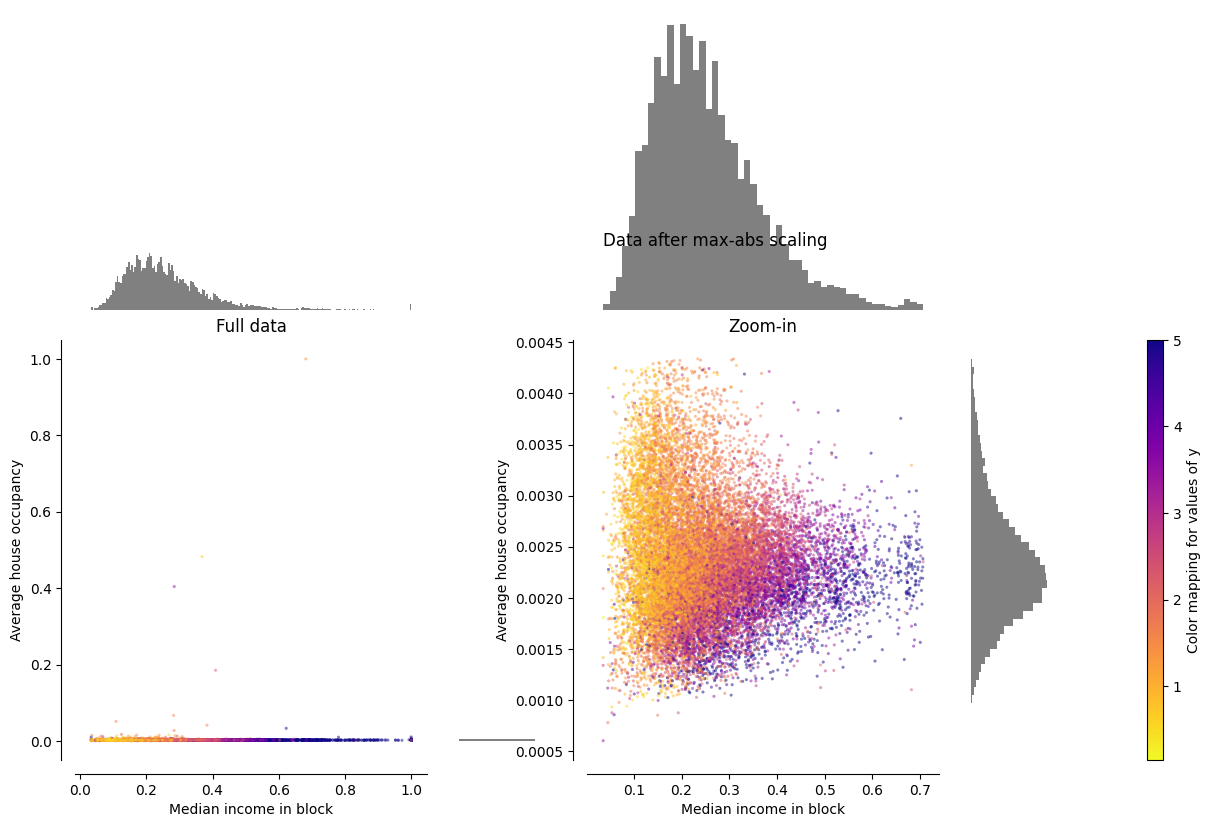

In [32]:
# @title Texto de título predeterminado
text10 = display_html('MaxAbs Scaling',
                      '- Este escalamiento divide cada elemento por el valor máximo absoluto de cada característica (feature) respectivamente, de tal forma que el valor máximo queda en 1.0.',
                      '- Este tipo de escalamiento no reduce el efecto de los outliers; solo los escala linealmente.')
display(html_display(text10))
make_plot(3)

$$X_{escalado} = \frac{X}{\max(|X|)}$$


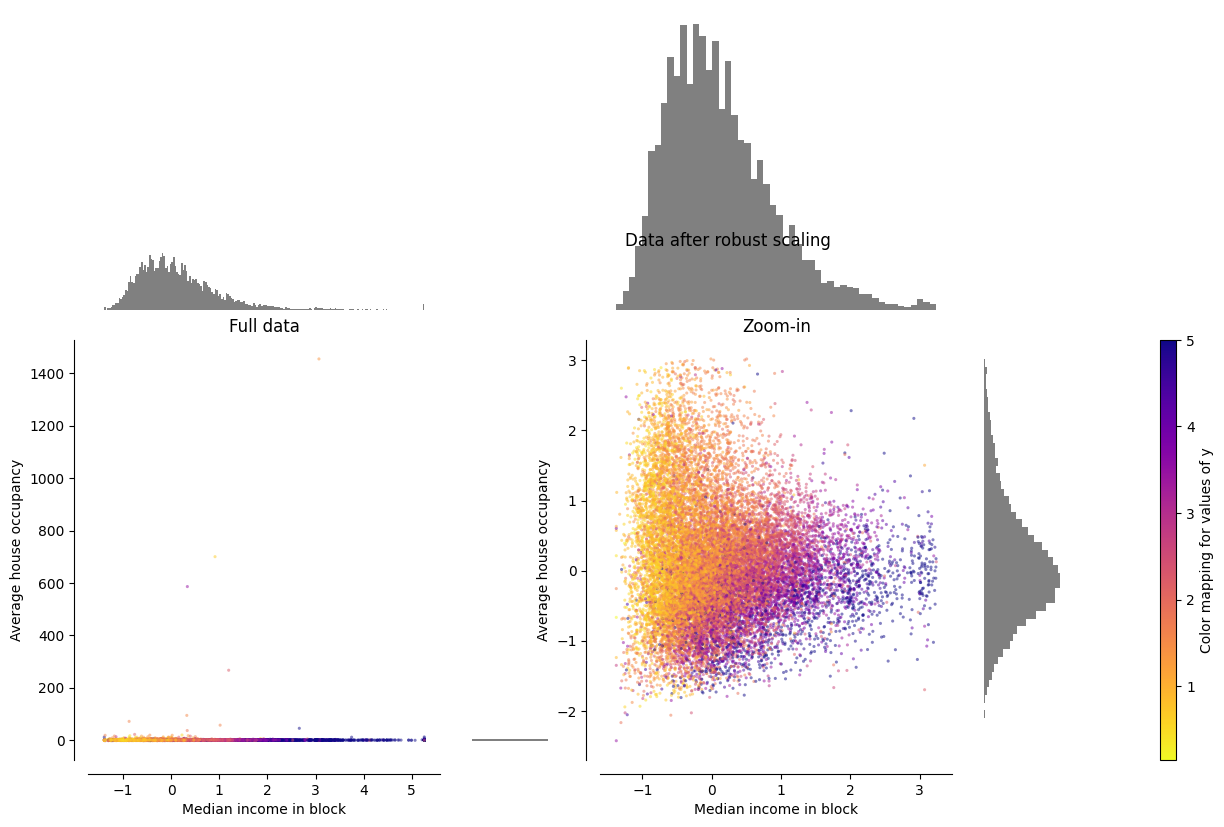

In [33]:
# @title Texto de título predeterminado
text10 = display_html('Robust Scaling',
                      '- A cada elemento le resta la mediana y lo divide por el rango intercuartílico (Q3-Q1), diferencia entre el rango del 50% de los datos centrales.',
                      '- Comparando RobustScaler y StandardScaler, me doy cuenta de que StandardScaler tiene un escalamiento más "ordenado" o proporcionado. Esto ocurre ya que, a diferencia de RobustScaler, la desviación estándar se ve afectada por los outliers de ambas features, lo que hace que al momento de escalar, los datos normales tengan una variación mínima o estén muy pegados unos de otros. RobustScaler utiliza la mediana y el rango intercuartílico (medidas que no son afectadas por los outliers); esto permite distribuir de mejor manera los datos normales y aislar los valores atípicos.',
                      '- Sin embargo, este aislamiento no es suficiente, ya que la desproporción de los valores altos rompe con la distribución de los datos.'
                    )
display(html_display(text10))
make_plot(4)

$$X_{escalado} = \frac{X - \text{Mediana}(X)}{Q_3(X) - Q_1(X)}$$

In [34]:
# @title Texto de título predeterminado

text10 = display_html('Metodos No Lineales')
display(html_display(text10))

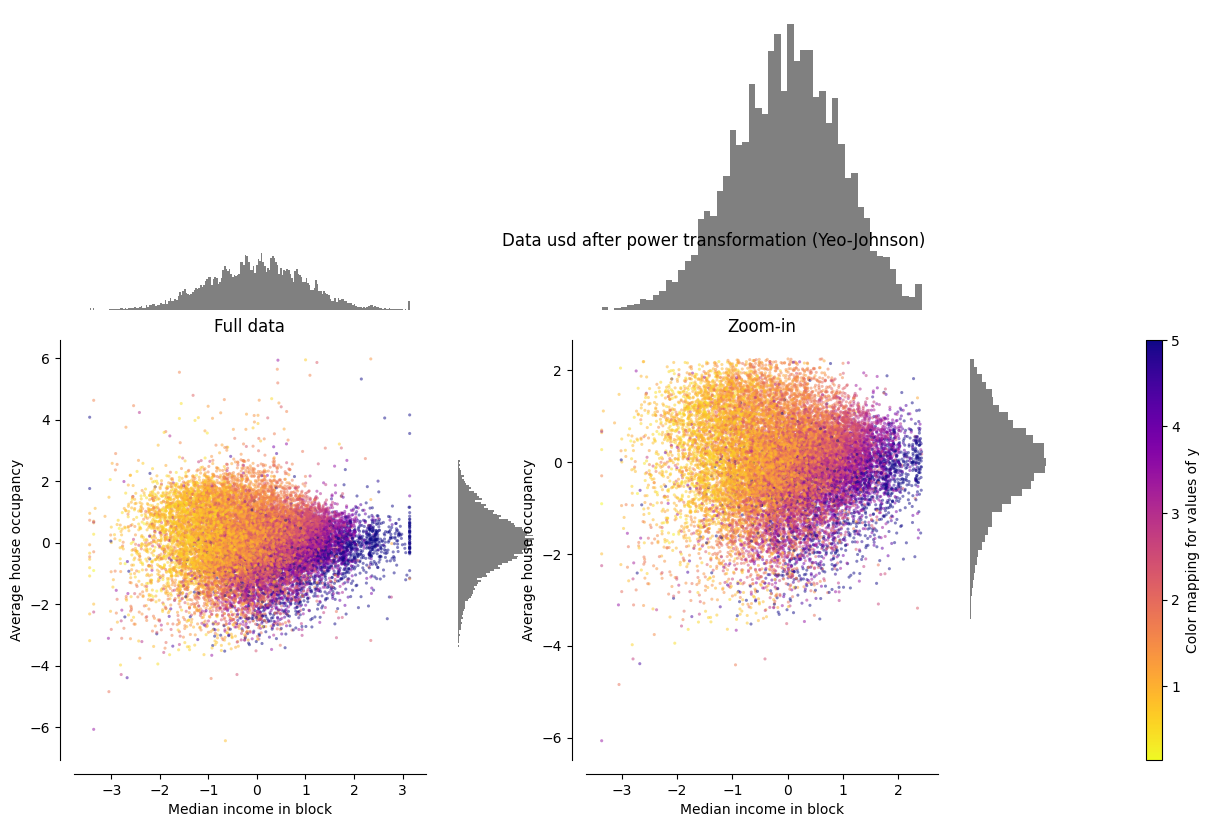

In [35]:
# @title Texto de título predeterminado
text10 = display_html('Power Transformation (Yeo-Johnson)',
                      '- Es una técnica de transformación estadística no lineal que pertenece al grupo de las transformaciones de potencia.',
                      '- Este método ajusta la forma geométrica de la distribución de los datos para que sea lo más parecida posible a una distribución normal, estabilizando la varianza y reduciendo la asimetría.',
                      '- Este tipo de método permite la transformación de valores negativos y ceros (a diferencia de Box-Cox).',
                      ('- Descripción del gráfico:', 'Se observa cómo la asimetría de los histogramas se reduce y la distribución se centra en comparación con los gráficos anteriores.')
                    )
display(html_display(text10))
make_plot(5)

$$
x_{trans} =
\begin{cases}
\frac{(x + 1)^\lambda - 1}{\lambda} & \text{si } \lambda \neq 0, x \geq 0 \\
\ln(x + 1) & \text{si } \lambda = 0, x \geq 0 \\
-\frac{(-x + 1)^{2 - \lambda} - 1}{2 - \lambda} & \text{si } \lambda \neq 2, x < 0 \\
-\ln(-x + 1) & \text{si } \lambda = 2, x < 0
\end{cases}
$$



- λ es el argumento define la fuerza o la dirección con la que se deben transformar los datos para que el resultado sea lo mas parecido a una distribución normal
- Sklearn utiliza el Estimación de Máxima Verosimilitud (MLE - Maximum Likelihood Estimation) para calcular el valor de λ
- dependiendo el valor de x y λ a x se le aplica una u otra regla


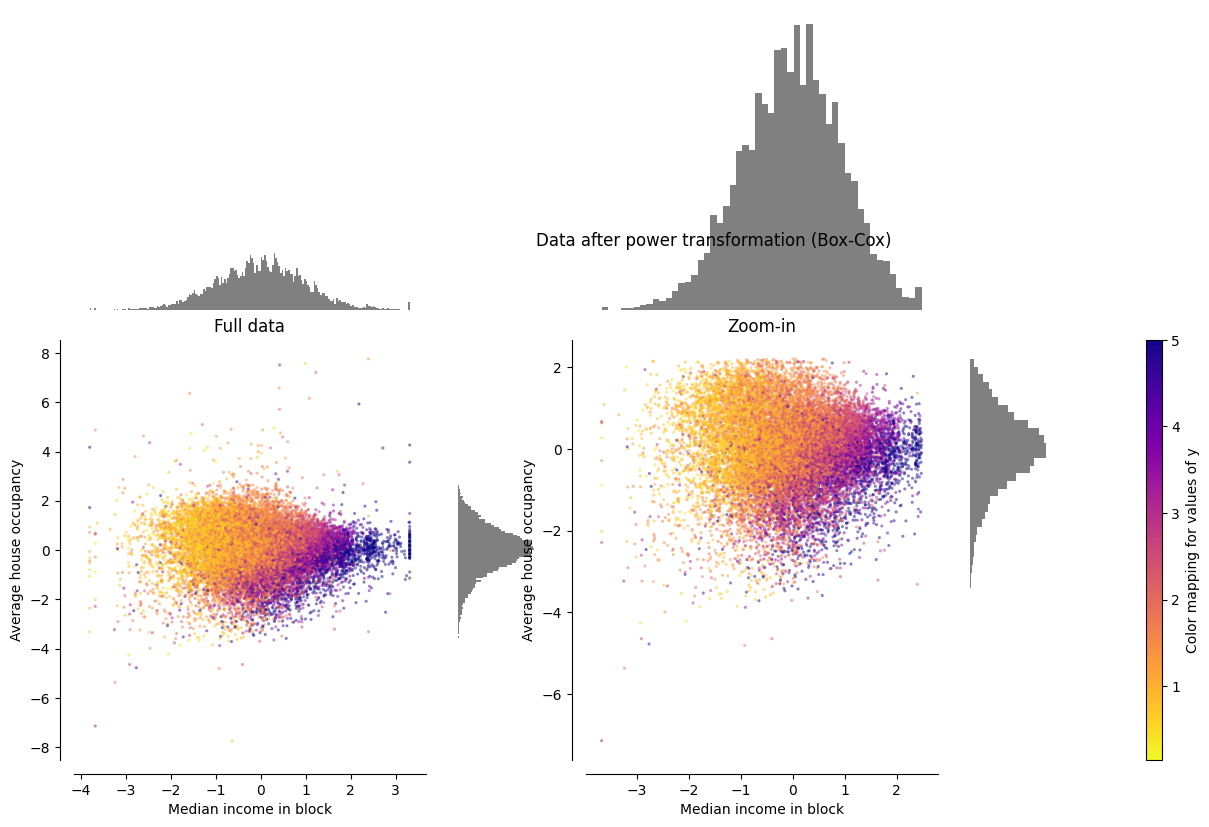

In [36]:
# @title Texto de título predeterminado
text10 = display_html('Power Transformation (Box-Cox)',
                      '- Al igual que Yeo-Johnson, Box-Cox es un método de transformación no lineal que escala los datos de forma que sean lo más similares posible a una distribución normal.',
                      '- Este posee una restricción crítica: los datos a transformar deben ser estrictamente positivos (mayores a cero). Por ende, a diferencia de Yeo-Johnson, los casos de la fórmula se reducen a dos.')
display(html_display(text10))
make_plot(6)

$$
x_{trans} =
\begin{cases}
\frac{x^\lambda - 1}{\lambda} & \text{si } \lambda \neq 0 \\
\ln(x) & \text{si } \lambda = 0
\end{cases}
    X > 0
$$




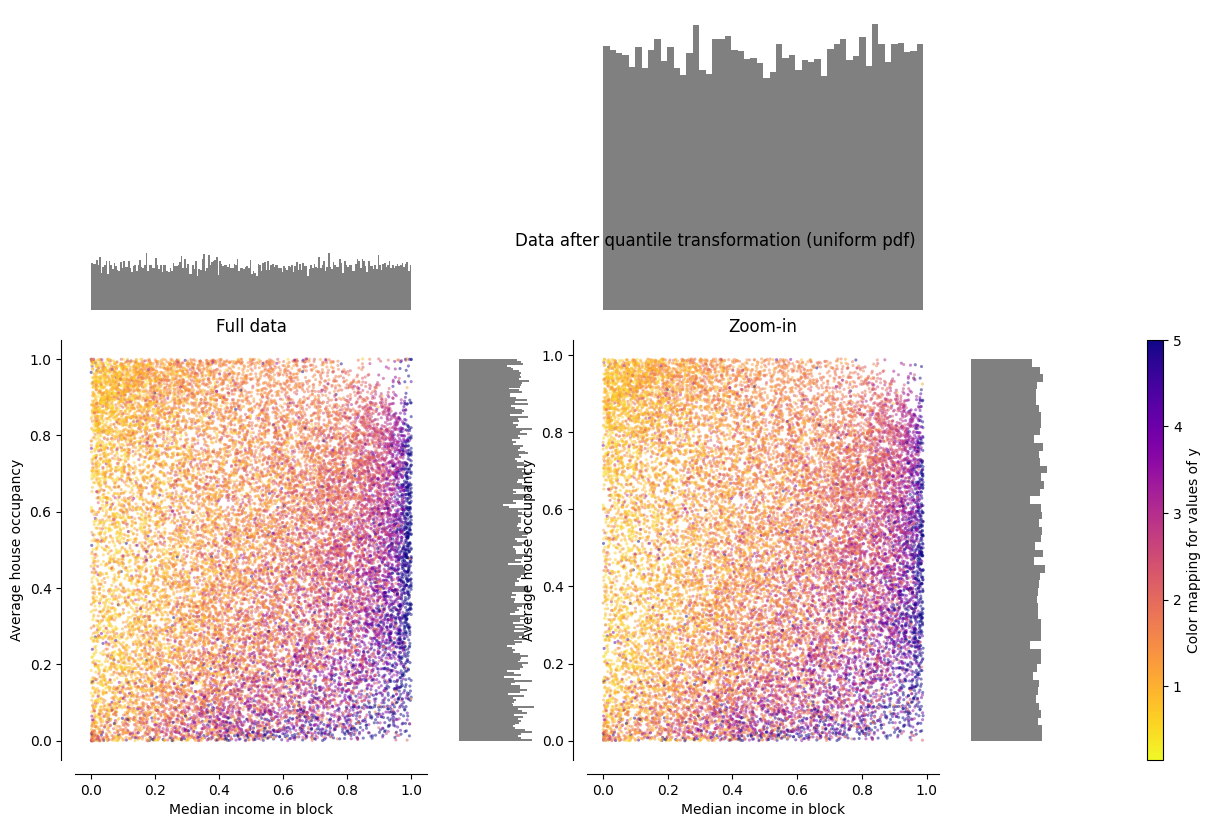

In [37]:
 # @title Texto de título predeterminado

text10 = display_html('Uniform pdf (Probability Density Function)',
                      '- Divide los datos en 1000 partes iguales (por defecto) y luego remplaza cada valor por un numero entre 0 y 1 que represente la pocición del cualtil en el que se encuentra el dato ')
display(html_display(text10))
make_plot(7)

$$
f(x) =
\begin{cases}
\frac{1}{b - a} & \text{para } a \le x \le b \\
0 & \text{fuera de ese rango}
\end{cases}
$$

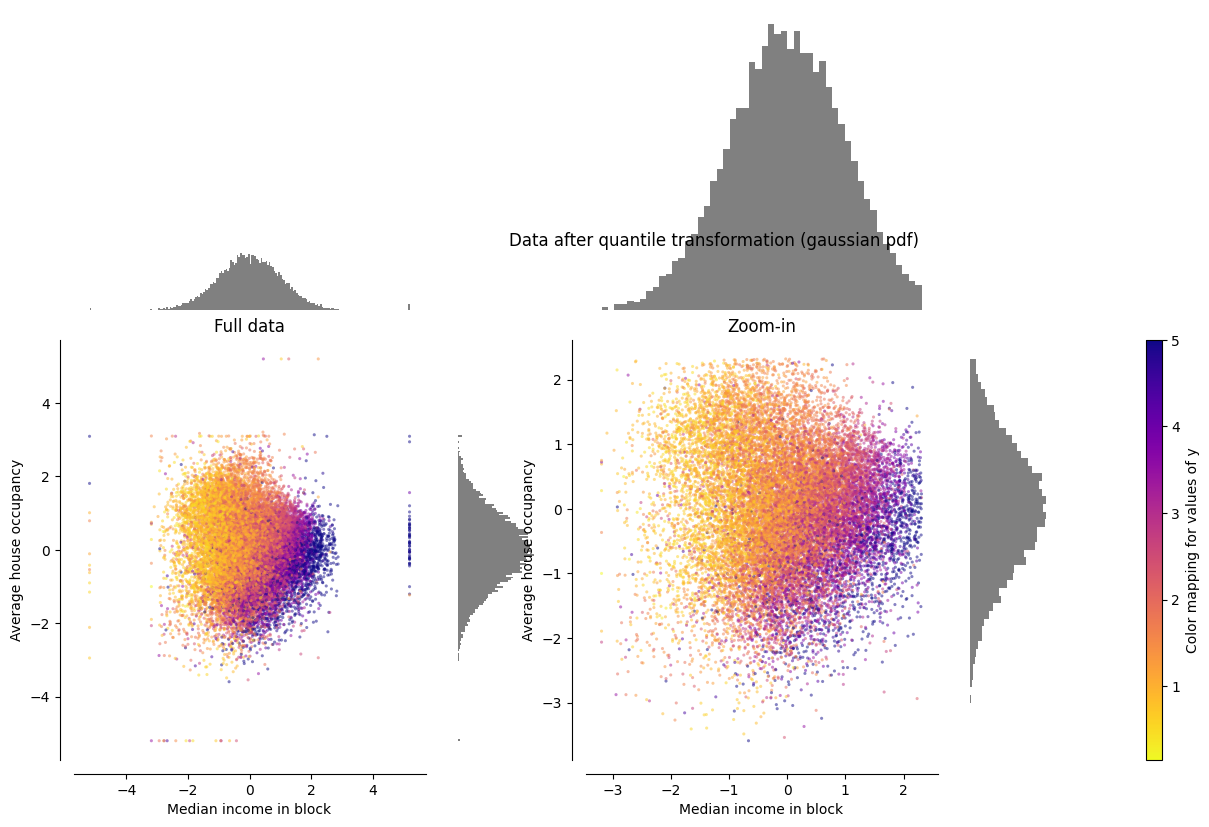

In [38]:
 # @title Texto de título predeterminado

text10 = display_html('Quantile Transformation (Gaussian PDF)',
                      '1 - Ordena los datos y los divide en 1000 cuantiles (por defecto), reemplazando cada valor original por su probabilidad acumulada (un número entre 0 y 1) según su posición.',
                      '2 - Mapeo Gaussiano (Función Probit) Utiliza esa probabilidad para calcular su valor correspondiente en una distribución normal estándar (Z-score) mediante la función inversa de la CDF .',
                      '3 - Resultado Final:</b> El dataset se transforma en una campana de Gauss perfecta con media 0 y varianza 1, eliminando el impacto de los outliers al mapearlos a los extremos controlados de la curva.')
display(html_display(text10))
make_plot(8)

## Respuestas al Cuestionario

### Transformación de Cuantiles con Distribución Gaussiana

Matemáticamente, la transformación gaussiana por cuantiles no se rige por una única ecuación algebraica continua, sino por la **composición de dos funciones estadísticas**:

$$x_{trans} = \Phi^{-1}(F_{emp}(x))$$

El proceso computacional se divide en dos fases exactas:

**1. Estimación de la Probabilidad Acumulada (ECDF)**
Primero, se proyecta la variable original ($x$) a un espacio uniforme continuo donde $p \in [0, 1]$. Esto se logra calculando la Función de Distribución Acumulada Empírica ($F_{emp}$), que evalúa la proporción de datos menores o iguales a $x$:

$$p = \frac{1}{N} \sum_{i=1}^{N} I(X_i \le x)$$

* $N$: Número total de observaciones.
* $I$: Función indicadora.

**2. Mapeo a Puntuación Z (Función Probit)**
Segundo, se aplica la inversa de la Función de Distribución Acumulada de la normal estándar ($\Phi^{-1}$), también conocida como función cuantil o Probit, sobre el valor $p$. Esta operación mapea el percentil hacia su correspondiente puntuación Z (Z-score) en una campana de Gauss perfecta:

$$x_{trans} = \sqrt{2} \cdot \text{erf}^{-1}(2p - 1)$$

> **⚠️ Nota de Implementación (Scikit-Learn):**
> A nivel computacional, si un valor extremo arrojara un percentil exacto de $p=0$ o $p=1$, el mapeo resultaría matemáticamente en infinitos ($\pm \infty$). Para evitar la destrucción del modelo, la librería aplica un recorte sintético (*clipping*), limitando de forma estricta los valores de $p$ al intervalo $[10^{-7}, 1 - 10^{-7}]$.

In [39]:
# @title Texto de título predeterminado
text10 = display_html(
    '1. Sensibilidad a los valores atípicos',
    ('Observa las gráficas de StandardScaler y MinMaxScaler. ¿Qué sucede con la masa principal de los datos (el "cuadrado" denso) cuando hay valores atípicos muy alejados? ¿Por qué estos escaladores podrían ser problemáticos en este escenario?'),
     'Al escalar los datos, la masa principal se encuentra comprimida en un rango de variación muy pequeño. Esto resulta poco óptimo para entrenar un modelo de regresión lineal, ya que el algoritmo pierde la capacidad de distinguir las sutiles diferencias entre los datos normales al estar todos "amontonados" cerca del mismo valor.')
display(html_display(text10))

In [40]:
# @title Texto de título predeterminado
text10 = display_html(
    '2. Robustez',
    ('Compara el RobustScaler con el StandardScaler. Explica por qué el RobustScaler logra mantener el "zoom" en la mayoría de los datos a pesar de que los ejes sigan mostrando los valores extremos. ¿Qué estadísticos utiliza para lograr esto?'),
     '- RobustScaler ofrece un escalamiento más representativo de la distribución real de los datos. Al utilizar estadísticas robustas (Mediana e IQR) en lugar de métricas sensibles (Media y Desviación Estándar), evita que los valores atípicos "inflen" la escala. Esto preserva la resolución de los datos normales, permitiendo que el modelo identifique patrones en la masa principal en lugar de colapsarlos en un rango insignificante.'
)
display(html_display(text10))

In [41]:
# @title Texto de título predeterminado
text10 = display_html(
    '3. Normalización de la distribución',
    ('El PowerTransformer (método Yeo-Johnson) y el QuantileTransformer (salida Gaussiana) intentan forzar los datos hacia una distribución normal.'),
    ('¿Qué diferencias visuales notas entre ellos?'),
    ('¿En qué tipo de modelos de aprendizaje automático crees que sería más beneficioso usar estas transformaciones en lugar de un simple escalado lineal?'),
    '- Gaussian Naive Bayes, redes neuronales, Análisis Discriminante Lineal, básicamente se utiliza en modelos donde se presupone que se trabaja con una distribución normal de datos y donde los pesos influyen de gran manera funcionando como multiplicadores de Importancia'
)
display(html_display(text10))

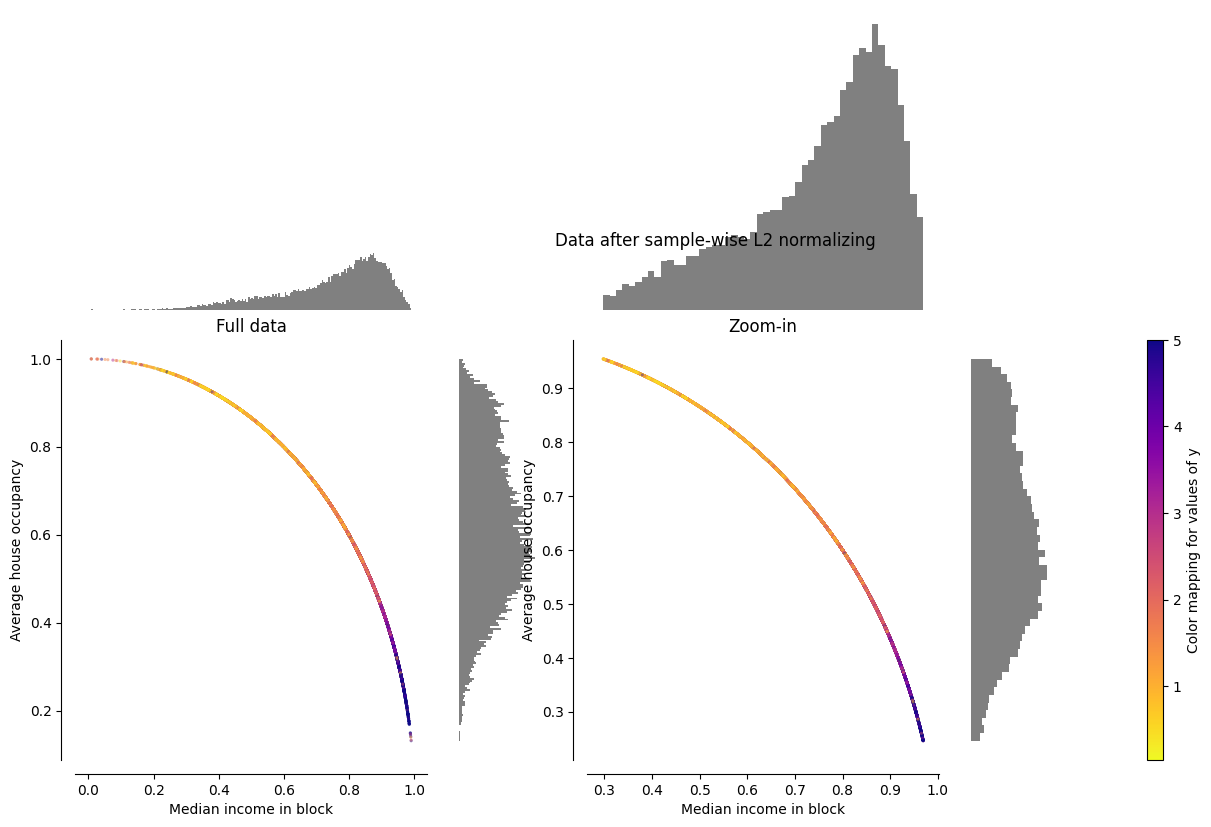

In [42]:
# @title Texto de título predeterminado
text10 = display_html(
    '4. El caso del Normalizer',
    ('El Normalizer muestra un gráfico muy distinto a todos los demás (con una forma circular o arqueada).'),
    ('¿Por qué este escalador actúa sobre las filas (muestras) en lugar de las columnas (características)?'),
    ('Investiga un caso de uso (como procesamiento de texto o química) donde este comportamiento sea deseable.'),
    '- Normalize es un método de preprocesamiento de datos que ajusta cada muestra, o fila del dataset, de forma que su norma, o magnitud, sea igual a 1. Esto sirve para que las comparaciones entre puntos sean más justas, sobre todo en algoritmos que se basan en distancias',
    '1- rocesamiento de Texto (Similitud de Documentos) en un caso donde se este comparando dos documentos para saber si hablan de lo mismo usando una técnica de "Bolsa de Palabras" (Bag of Words):Documento A: Es un tuit corto que menciona 1 vez "IA" y 1 vez "Datos".Documento B: Es un artículo largo que menciona 50 veces "IA" y 50 veces "Datos".Si usás las frecuencias crudas, un algoritmo de clustering dirá que son documentos totalmente distintos porque el Documento B tiene números muchísimo más grandes. Sin embargo, temáticamente son idénticos (ambos tienen un 50% de cada tema).Al aplicar Normalizer sobre las filas, ambos documentos se transforman en vectores de igual magnitud. Esto permite que el modelo mida la distancia angular (similitud coseno) entre ellos, ignorando qué tan largo o corto es el texto y enfocándose solo en el "perfil" del contenido.'
)
display(html_display(text10))
make_plot(9)

$$\|x\|_2 = \sqrt{x_1^2 + x_2^2 + \dots + x_n^2}$$

$$z = \frac{x}{\|x\|}$$

In [43]:
# @title Texto de título predeterminado
text10 = display_html(
    '5. Conclusión técnica',
    ('Si estuvieras entrenando un modelo de regresión lineal para predecir el precio de las casas y notas que la variable "ingreso medio" tiene muchos valores atípicos, ¿cuál de todos los métodos probados elegirías y por qué?'),
     'Si estuviera que entrenar un modelo de regresión lineal utilizaria el metodo más simple y eficiente que se adapte a mi rango de valores y a la distorción de los valores atipicos, si es un caso extremo como este utilizaria Power Transformation (Box-Cox) ya que este conjunto de datos maneja un rango de valores positivo y este metodo me ayudaria a asemejar el conjunto de datos, a una distribución normal, importante para la precisión de un modelo de regresión lineal'
)
display(html_display(text10))

